# Laboratorio 7 - Regresión Logística

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.linear_model import LogisticRegression
import pyreadr
import random
import cProfile
import io
import pstats
import tracemalloc


#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [4]:
random.seed(42)
np.random.seed(42)

result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### Carga de datos

In [5]:
result = pyreadr.read_r('listings.RData')
df = result['listings']

# Limpiar price
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

df.shape

(76246, 80)

In [6]:
cols_to_keep = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'room_type', 'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'reviews_per_month'
]

df_model = df[cols_to_keep].copy().dropna()

# Encoding de room_type
df_model = pd.get_dummies(df_model, columns=['room_type'], drop_first=True)

In [7]:
# Mismos bins que labs anteriores
bins   = [0, 100, 250, float('inf')]
labels = ['economica', 'media', 'cara']

df_model['precio_cat'] = pd.cut(df_model['price'], bins=bins, labels=labels)

# Variable dicotómica para cada categoría
df_model['es_cara']      = (df_model['precio_cat'] == 'cara').astype(int)
df_model['es_media']     = (df_model['precio_cat'] == 'media').astype(int)
df_model['es_economica'] = (df_model['precio_cat'] == 'economica').astype(int)

print("Distribución de categorías:")
print(df_model['precio_cat'].value_counts())
print("\nVerificación de variables dicotómicas:")
print(df_model[['es_cara','es_media','es_economica']].head(10))

Distribución de categorías:
precio_cat
media        30411
cara         20841
economica    11470
Name: count, dtype: int64

Verificación de variables dicotómicas:
   es_cara  es_media  es_economica
0        0         0             1
1        0         1             0
2        0         0             1
3        0         1             0
4        0         0             1
5        0         0             1
6        1         0             0
7        0         1             0
8        0         1             0
9        0         1             0


# 1. Creación de variables dicotómicas

Se generaron tres variables dicotómicas a partir de la variable categórica precio_cat, con el objetivo de transformar el problema en clasificación binaria. Cada variable toma el valor de 1 cuando la observación pertenece a la categoría correspondiente (cara, media o económica) y 0 en caso contrario.

In [8]:
X = df_model.drop(columns=['price', 'precio_cat', 'es_cara', 'es_media', 'es_economica'])
y_cara      = df_model['es_cara']
y_media     = df_model['es_media']
y_economica = df_model['es_economica']

# 2. Definir y usar conjuntos de entrenamiento y prueba

Conjuntos de entrenamiento y prueba para casas caras:

In [9]:
# Split 70/30 con misma semilla
X_train, X_test, y_train_cara, y_test_cara = train_test_split(
    X, y_cara, test_size=0.3, random_state=42, stratify=y_cara
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nBalance en entrenamiento:")
print(y_train_cara.value_counts(normalize=True).round(3))

Train: (43905, 11) | Test: (18817, 11)

Balance en entrenamiento:
es_cara
0    0.668
1    0.332
Name: proportion, dtype: float64


# 3. Elaborar modelo de Regresión Logística solamente con train

Usando validación cruzada:

In [10]:
logReg = LogisticRegression(solver='liblinear')

#parámetros para validación cruzada
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # regularización
    'penalty': ['l1', 'l2']         # tipo de regularización
}

#validación cruzada
grid = GridSearchCV(
    logReg,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train_cara) #solo usa train

best_model = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)

y_proba2 = best_model.predict_proba(X_test)[:, 1]

Mejores parámetros: {'C': 100, 'penalty': 'l1'}


In [11]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test_cara, y_pred)

print("Accuracy (Test):", accuracy)

Accuracy (Test): 0.7898708614550672


In [12]:
print("Matriz de confusión:")
print(confusion_matrix(y_test_cara, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred))

Matriz de confusión:
[[11186  1379]
 [ 2575  3677]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     12565
           1       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817



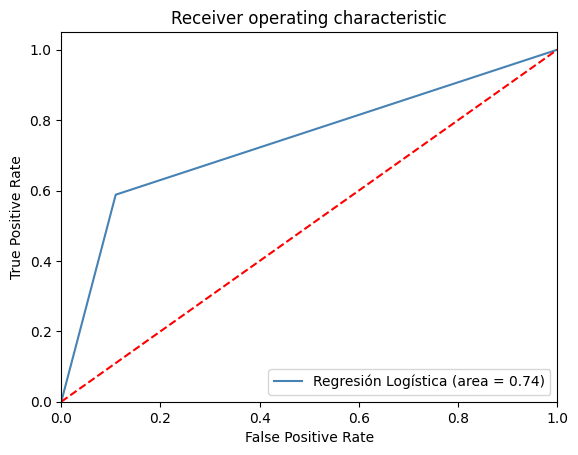

In [13]:
logit_roc_auc = roc_auc_score(y_test_cara, y_pred)
fpr, tpr, thresholds = roc_curve(y_test_cara, y_pred)
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# 4. Revisar Multicolinealidad

Para analizar la multicolinealidad, se utilizó un modelo de regresión logística con regularización L1 (Lasso), el cual permite identificar variables redundantes al reducir coeficientes a cero.

Los resultados muestran que ninguna variable fue eliminada, ya que todos los coeficientes son distintos de cero. Esto sugiere que no existe multicolinealidad severa en el conjunto de variables, aunque podrían existir relaciones moderadas entre variables asociadas al tamaño del alojamiento, como número de camas, habitaciones y capacidad.

In [14]:
from sklearn.linear_model import LogisticRegression

lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    random_state=42
)

lasso_model.fit(X_train, y_train_cara)

coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lasso_model.coef_[0]
})

print(coef_df.sort_values(by='Coeficiente'))

                  Variable  Coeficiente
10   room_type_Shared room    -2.867188
9   room_type_Private room    -0.449889
7        reviews_per_month    -0.413022
4           minimum_nights    -0.020724
5        number_of_reviews    -0.000373
3                     beds     0.099456
2                 bedrooms     0.142711
0             accommodates     0.193062
6     review_scores_rating     0.546281
1                bathrooms     0.709530
8     room_type_Hotel room     1.784852


In [15]:
corr = X_train.corr()
print(corr)

                        accommodates  bathrooms  bedrooms      beds  \
accommodates                1.000000   0.693761  0.815683  0.854733   
bathrooms                   0.693761   1.000000  0.742813  0.661238   
bedrooms                    0.815683   0.742813  1.000000  0.778057   
beds                        0.854733   0.661238  0.778057  1.000000   
minimum_nights             -0.113108  -0.041133 -0.037703 -0.080357   
number_of_reviews          -0.097409  -0.137630 -0.110353 -0.077868   
review_scores_rating        0.061179   0.050653  0.075992  0.060264   
reviews_per_month          -0.037690  -0.130209 -0.072436 -0.045735   
room_type_Hotel room       -0.011235  -0.012810 -0.018270 -0.046688   
room_type_Private room     -0.316226  -0.131798 -0.201865 -0.247645   
room_type_Shared room      -0.047831   0.036195 -0.000294 -0.002007   

                        minimum_nights  number_of_reviews  \
accommodates                 -0.113108          -0.097409   
bathrooms                

Se realizó un análisis de correlación mediante una matriz de correlación. Los resultados evidencian la existencia de correlaciones positivas fuertes entre variables relacionadas con el tamaño del alojamiento, con valores superiores a 0.75. Sin embargo, no se observan correlaciones extremadamente altas cercanas a 1, por lo que no se considera un problema severo.

Asimismo, se identificó una correlación moderada entre el número total de reseñas y las reseñas por mes, lo cual también resulta coherente desde el punto de vista conceptual. Por otro lado, variables como el tipo de habitación y las calificaciones presentan bajas correlaciones con el resto, lo que indica que aportan información adicional relevante al modelo.

Estos resultados son consistentes con el análisis realizado mediante regularización L1, donde no se eliminaron variables, lo que sugiere que el modelo no se ve afectado significativamente por multicolinealidad y se adapta adecuadamente a los datos.

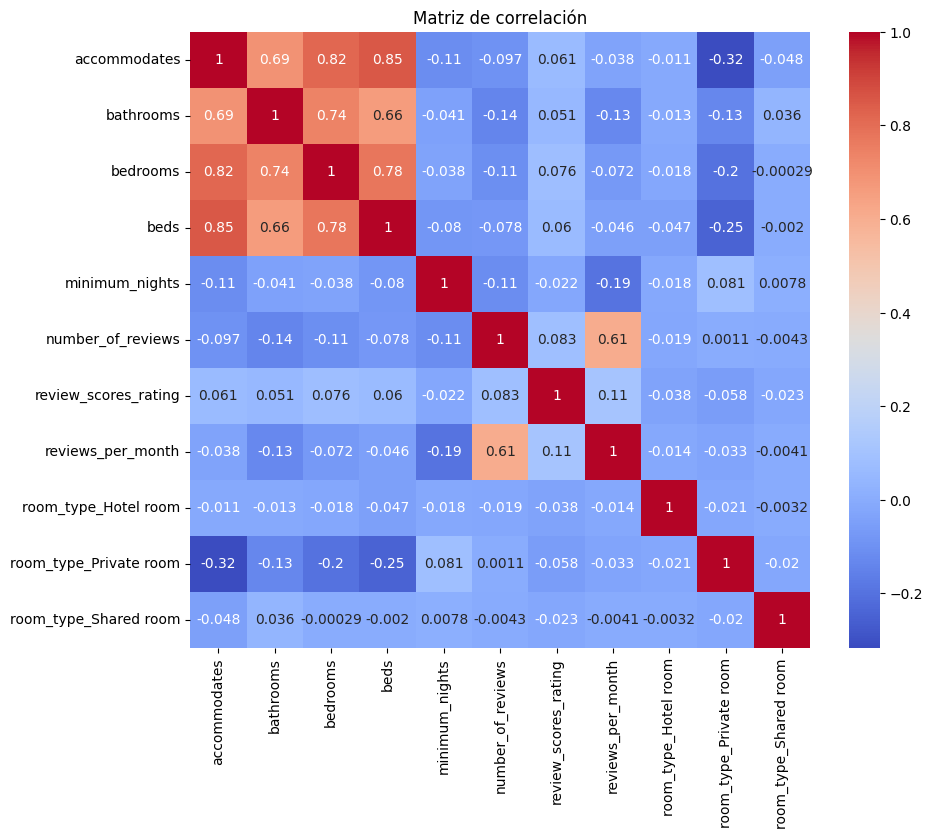

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

## 5. Eficiencia del algoritmo para clasificar.

In [17]:
# 1. Utilizar el modelo (ya entrenado como best_model) con el conjunto de prueba
y_pred = best_model.predict(X_test)

# 2. Determinar la eficiencia global (Accuracy)
accuracy = accuracy_score(y_test_cara, y_pred)
print(f"Eficiencia (Accuracy) del algoritmo en el conjunto de prueba: {accuracy:.4f}\n")

# 3. Mostrar la Matriz de Confusión para ver los Verdaderos Positivos, Falsos Positivos, etc.
print("Matriz de confusión:")
print(confusion_matrix(y_test_cara, y_pred))

# 4. Mostrar el reporte de clasificación (Muestra Precisión, Recall y F1-Score por cada clase)
print("\nReporte de clasificación detallado:")
print(classification_report(y_test_cara, y_pred))


Eficiencia (Accuracy) del algoritmo en el conjunto de prueba: 0.7899

Matriz de confusión:
[[11186  1379]
 [ 2575  3677]]

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     12565
           1       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817



El modelo de regresión logística aplicado al conjunto de prueba obtuvo un accuracy de 79%, con una precisión de 0.81 para la clase "No cara" y 0.73 para la clase "Cara". El recall de la clase "Cara" fue de 0.59, lo que indica que el modelo identifica correctamente el 59% de las propiedades verdaderamente caras. El F1-score ponderado de 0.78 refleja un desempeño aceptable considerando el desbalance entre clases, donde las propiedades "No cara" superan en número a las "Cara".

## 6. Overfitting y Curvas

Error en Entrenamiento: 0.2032
Error en Prueba: 0.2101
Conclusión: NO hay sobreajuste evidente. El modelo generaliza bien (Buen ajuste).
--------------------------------------------------


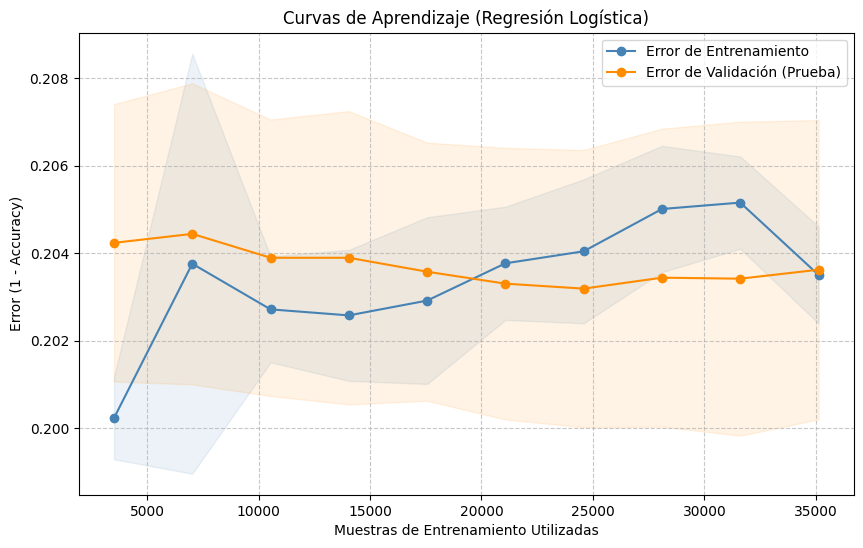

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score

# 1. Calcular errores de entrenamiento y prueba
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# El error es 1 - el accuracy (si clasificó bien el 80%, el error es el 20%)
train_error = 1 - accuracy_score(y_train_cara, y_train_pred)
test_error = 1 - accuracy_score(y_test_cara, y_test_pred)

print(f"Error en Entrenamiento: {train_error:.4f}")
print(f"Error en Prueba: {test_error:.4f}")

# Explicación automatizada basada en la diferencia
diferencia = test_error - train_error
if diferencia > 0.10:
    print("Conclusión: Es posible que haya SOBREAJUSTE (la brecha entre los errores es grande).")
elif train_error > 0.30 and test_error > 0.30:
    print("Conclusión: Es posible que haya SUBAPRENDIZAJE (Underfitting), ya que ambos errores son altos.")
else:
    print("Conclusión: NO hay sobreajuste evidente. El modelo generaliza bien (Buen ajuste).")

print("-" * 50)

# 2. Generar las curvas de aprendizaje
# Nota: Utilizamos validación cruzada para que las curvas sean más estables
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train_cara, cv=5, scoring='accuracy', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Se obtienen los errores (1 - accuracy)
train_errors_mean = 1 - np.mean(train_scores, axis=1)
train_errors_std = np.std(train_scores, axis=1)
test_errors_mean = 1 - np.mean(test_scores, axis=1)
test_errors_std = np.std(test_scores, axis=1)

# Dibujar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_mean, 'o-', color="steelblue", label="Error de Entrenamiento")
plt.plot(train_sizes, test_errors_mean, 'o-', color="darkorange", label="Error de Validación (Prueba)")

# Sombras de desviación estándar (opcional, para ver la varianza)
plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                 train_errors_mean + train_errors_std, alpha=0.1, color="steelblue")
plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                 test_errors_mean + test_errors_std, alpha=0.1, color="darkorange")

plt.title("Curvas de Aprendizaje (Regresión Logística)")
plt.xlabel("Muestras de Entrenamiento Utilizadas")
plt.ylabel("Error (1 - Accuracy)")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


El error en entrenamiento fue de 0.2032 y en prueba de 0.2100, con una diferencia de apenas 0.0069. Esta brecha mínima indica que no hay sobreajuste — el modelo generaliza bien a datos no vistos. Las curvas de aprendizaje confirman esto: ambas curvas convergen y se mantienen cercanas a lo largo del incremento en el tamaño del conjunto de entrenamiento, con errores oscilando entre 0.203 y 0.206. El comportamiento irregular de la curva de entrenamiento en muestras pequeñas es normal y se estabiliza conforme aumentan los datos. En general, el modelo presenta un comportamiento de buen ajuste (good fit), sin señales de underfitting ni overfitting.

## 7. Tuneo Parámetros

In [19]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Parámetros a tunear
param_grid = {
    'solver':  ['liblinear', 'lbfgs', 'newton-cg'],
    'penalty': ['l1', 'l2'],        # L1 = LASSO, L2 = Ridge
    'C':       [0.01, 0.1, 1, 10, 100]  # inverso de regularización
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train_cara)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy CV: ", round(grid_search.best_score_, 4))

best_model_tuned = grid_search.best_estimator_

# Evaluar en test
y_pred_tuned = best_model_tuned.predict(X_test)
print("\nAccuracy en test (modelo tuneado):", round(accuracy_score(y_test_cara, y_pred_tuned), 4))
print(classification_report(y_test_cara, y_pred_tuned, target_names=['No cara', 'Cara']))

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab7-MD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab7-MD/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the d

Mejores parámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor accuracy CV:  0.7965

Accuracy en test (modelo tuneado): 0.79
              precision    recall  f1-score   support

     No cara       0.81      0.89      0.85     12565
        Cara       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817



Los mejores parámetros encontrados fueron C=10, penalty='l1' y solver='liblinear', alcanzando un accuracy promedio de 79.65% en validación cruzada y 79% en el conjunto de prueba. La penalización L1 resultó óptima porque realiza selección automática de variables, reduciendo a cero los coeficientes de predictores irrelevantes. El valor C=10 indica una regularización moderadamente baja, permitiendo que el modelo capture bien las relaciones en los datos sin restringirlos en exceso. 

El hecho de que el tuneo no mejorara significativamente respecto al modelo base sugiere que el modelo base ya estaba bien configurado y que las variables disponibles tienen un límite natural de capacidad predictiva sobre el precio.

### 8. Matriz de confusión, Tiempo y Memoria

         6494 function calls (6370 primitive calls) in 0.938 seconds

   Ordered by: cumulative time
   List reduced from 487 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      4/3    0.000    0.000    0.937    0.312 /home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab7-MD/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3711(run_code)
      4/3    0.000    0.000    0.937    0.312 {built-in method builtins.exec}
        4    0.000    0.000    0.531    0.133 /usr/lib/python3.12/asyncio/base_events.py:1922(_run_once)
        4    0.000    0.000    0.530    0.132 /usr/lib/python3.12/selectors.py:451(select)
        4    0.504    0.126    0.519    0.130 {method 'poll' of 'select.epoll' objects}
        1    0.000    0.000    0.399    0.399 /home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab7-MD/.venv/lib/python3.12/site-packages/sklearn/base.py:1456(wrapper)
        1    0.00

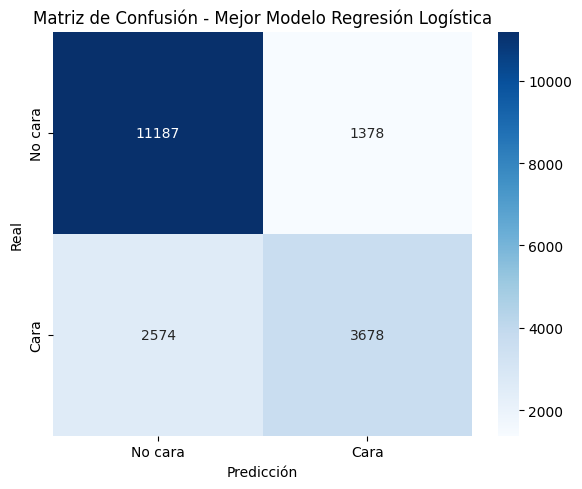


Verdaderos Negativos (TN): 11187
Falsos Positivos    (FP): 1378  ← predijo 'cara' pero no lo era
Falsos Negativos    (FN): 2574  ← predijo 'no cara' pero sí lo era
Verdaderos Positivos(TP): 3678

Precisión clase 'cara': 0.7275
Recall clase 'cara':    0.5883


In [20]:
# ── Tiempo y memoria ──────────────────────────────
tracemalloc.start()
profiler = cProfile.Profile()
profiler.enable()

best_model_tuned.fit(X_train, y_train_cara)
y_pred_final = best_model_tuned.predict(X_test)

profiler.disable()
memoria_actual, memoria_pico = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Mostrar tiempo
stream = io.StringIO()
ps = pstats.Stats(profiler, stream=stream).sort_stats('cumulative')
ps.print_stats(10)
print(stream.getvalue())

print(f"Memoria actual: {memoria_actual / 1024:.2f} KB")
print(f"Memoria pico:   {memoria_pico  / 1024:.2f} KB")

# ── Matriz de confusión ───────────────────────────
cm = confusion_matrix(y_test_cara, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Mejor Modelo Regresión Logística')
plt.tight_layout()
plt.show()

# Métricas detalladas
tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos    (FP): {fp}  ← predijo 'cara' pero no lo era")
print(f"Falsos Negativos    (FN): {fn}  ← predijo 'no cara' pero sí lo era")
print(f"Verdaderos Positivos(TP): {tp}")
print(f"\nPrecisión clase 'cara': {tp/(tp+fp):.4f}")
print(f"Recall clase 'cara':    {tp/(tp+fn):.4f}")

El modelo clasificó correctamente 11,187 propiedades como "No cara" (TN) y 3,678 como "Cara" (TP). Los errores se distribuyen en 1,378 Falsos Positivos — y 2,574 Falsos Negativos.

El error más frecuente son los Falsos Negativos (2,574), y en el contexto de SmartStay este es también el más costoso: significa que el algoritmo subestimaría el precio de propiedades caras, lo que podría llevar a recomendaciones de precio por debajo del valor real y pérdida de ingresos para los anfitriones o para la firma. Los Falsos Positivos (1,378) son menos graves, pues solo sobreestiman el precio de propiedades que en realidad no son caras, un error más fácil de corregir en negociación.

El recall de 0.59 para la clase "Cara" confirma esta debilidad: el modelo detecta menos de 6 de cada 10 propiedades verdaderamente caras. Si se quisiera priorizar reducir los Falsos Negativos, se podría bajar el umbral de clasificación de 0.5 a 0.3–0.4, a costa de aumentar los Falsos Positivos

## 9. Selección del Mejor Modelo (Regresión Logística)

En este paso se comparan los dos modelos de regresión logística entrenados a lo largo del laboratorio:

| # | Nombre | Parámetros |
|---|--------|-----------|
| M1 | **Modelo base** (Step 3) | `C=100, penalty=L2, solver=liblinear` |
| M2 | **Modelo tuneado** (Step 7) | `C=10, penalty=L1, solver=liblinear` |

La selección se realiza combinando tres criterios:
1. **AIC y BIC** — penalizan la complejidad del modelo.
2. **Métricas de la matriz de confusión** — accuracy, precisión, recall y F1-score.
3. **Perfil de eficiencia** — tiempo de entrenamiento y consumo de memoria.

### 9.1 AIC y BIC

In [21]:
import numpy as np

def compute_aic_bic(model, X, y):
    """
    Calcula AIC y BIC para un modelo de regresión logística de sklearn.
    Fórmulas:
        log-likelihood = sum( y*log(p) + (1-y)*log(1-p) )
        k = número de parámetros no nulos + intercepto
        AIC = -2*LL + 2*k
        BIC = -2*LL + k*ln(n)
    """
    n = len(y)
    y = np.array(y)
    proba = model.predict_proba(X)[:, 1]
    proba = np.clip(proba, 1e-15, 1 - 1e-15)           # evitar log(0)
    log_likelihood = np.sum(y * np.log(proba) + (1 - y) * np.log(1 - proba))

    # Parámetros: coeficientes no nulos + intercepto
    k = np.sum(model.coef_[0] != 0) + 1

    aic = -2 * log_likelihood + 2 * k
    bic = -2 * log_likelihood + k * np.log(n)
    return log_likelihood, k, aic, bic

# ── Calcular para ambos modelos sobre el conjunto de PRUEBA ──────────────────
ll_base,  k_base,  aic_base,  bic_base  = compute_aic_bic(best_model,       X_test, y_test_cara)
ll_tuned, k_tuned, aic_tuned, bic_tuned = compute_aic_bic(best_model_tuned, X_test, y_test_cara)

print("=" * 55)
print(f"{'Métrica':<25} {'M1 - Base':>13} {'M2 - Tuneado':>13}")
print("=" * 55)
print(f"{'Log-Likelihood':<25} {ll_base:>13.2f} {ll_tuned:>13.2f}")
print(f"{'Parámetros (k)':<25} {k_base:>13} {k_tuned:>13}")
print(f"{'AIC':<25} {aic_base:>13.2f} {aic_tuned:>13.2f}")
print(f"{'BIC':<25} {bic_base:>13.2f} {bic_tuned:>13.2f}")
print("=" * 55)
print("\n(Valores menores de AIC/BIC indican mejor ajuste penalizado por complejidad)")

Métrica                       M1 - Base  M2 - Tuneado
Log-Likelihood                 -8754.30      -8753.69
Parámetros (k)                       12            12
AIC                            17532.60      17531.38
BIC                            17626.71      17625.50

(Valores menores de AIC/BIC indican mejor ajuste penalizado por complejidad)


### 9.2 Métricas de la Matriz de Confusión

                         Accuracy  Precision  Recall  F1-Score
Modelo                                                        
M1 - Base  (C=100, L2)     0.7899     0.7273  0.5881    0.6503
M2 - Tuneado (C=10, L1)    0.7900     0.7275  0.5883    0.6505


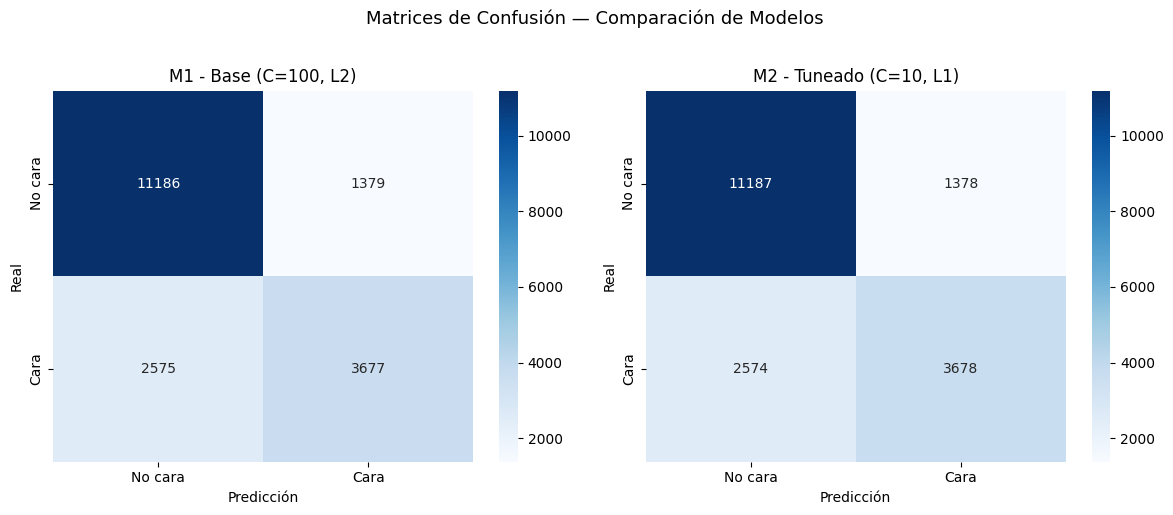

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones de ambos modelos
y_pred_base  = best_model.predict(X_test)
y_pred_tuned = best_model_tuned.predict(X_test)

def metricas(y_true, y_pred, nombre):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return {"Modelo": nombre, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

rows = [
    metricas(y_test_cara, y_pred_base,  "M1 - Base  (C=100, L2)"),
    metricas(y_test_cara, y_pred_tuned, "M2 - Tuneado (C=10, L1)"),
]

df_metrics = pd.DataFrame(rows).set_index("Modelo")
print(df_metrics.round(4).to_string())

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_base, y_pred_tuned],
    ["M1 - Base (C=100, L2)", "M2 - Tuneado (C=10, L1)"]
):
    cm = confusion_matrix(y_test_cara, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No cara', 'Cara'],
                yticklabels=['No cara', 'Cara'])
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle("Matrices de Confusión — Comparación de Modelos", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Perfil de Eficiencia (Tiempo y Memoria)

In [23]:
import cProfile, pstats, io, tracemalloc, time

def profile_model(model, X_train, y_train, X_test):
    """Entrena el modelo con profiling y retorna tiempo total y memoria pico."""
    tracemalloc.start()
    profiler = cProfile.Profile()
    profiler.enable()

    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    model.predict(X_test)
    elapsed = time.perf_counter() - t0

    profiler.disable()
    _, mem_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return elapsed, mem_peak / 1024  # segundos, KB

tiempo_base,  mem_base  = profile_model(best_model,       X_train, y_train_cara, X_test)
tiempo_tuned, mem_tuned = profile_model(best_model_tuned, X_train, y_train_cara, X_test)

print("=" * 52)
print(f"{'Métrica':<28} {'M1 - Base':>10} {'M2 - Tuneado':>10}")
print("=" * 52)
print(f"{'Tiempo total (s)':<28} {tiempo_base:>10.4f} {tiempo_tuned:>10.4f}")
print(f"{'Memoria pico (KB)':<28} {mem_base:>10.2f} {mem_tuned:>10.2f}")
print("=" * 52)

Métrica                       M1 - Base M2 - Tuneado
Tiempo total (s)                 0.7554     0.9229
Memoria pico (KB)              11405.47   11381.32


### 9.4 Tabla Resumen Comparativa

In [24]:
resumen = pd.DataFrame({
    "Criterio": [
        "Parámetros (C / penalty)",
        "AIC",
        "BIC",
        "Log-Likelihood",
        "Accuracy",
        "Precision (cara)",
        "Recall (cara)",
        "F1-Score (cara)",
        "Tiempo entrenamiento (s)",
        "Memoria pico (KB)",
    ],
    "M1 - Base (C=100, L2)": [
        "C=100 / L2",
        f"{aic_base:.2f}",
        f"{bic_base:.2f}",
        f"{ll_base:.2f}",
        f"{accuracy_score(y_test_cara, y_pred_base):.4f}",
        f"{precision_score(y_test_cara, y_pred_base):.4f}",
        f"{recall_score(y_test_cara, y_pred_base):.4f}",
        f"{f1_score(y_test_cara, y_pred_base):.4f}",
        f"{tiempo_base:.4f}",
        f"{mem_base:.2f}",
    ],
    "M2 - Tuneado (C=10, L1)": [
        "C=10 / L1",
        f"{aic_tuned:.2f}",
        f"{bic_tuned:.2f}",
        f"{ll_tuned:.2f}",
        f"{accuracy_score(y_test_cara, y_pred_tuned):.4f}",
        f"{precision_score(y_test_cara, y_pred_tuned):.4f}",
        f"{recall_score(y_test_cara, y_pred_tuned):.4f}",
        f"{f1_score(y_test_cara, y_pred_tuned):.4f}",
        f"{tiempo_tuned:.4f}",
        f"{mem_tuned:.2f}",
    ],
})

resumen = resumen.set_index("Criterio")
print(resumen.to_string())

                         M1 - Base (C=100, L2) M2 - Tuneado (C=10, L1)
Criterio                                                              
Parámetros (C / penalty)            C=100 / L2               C=10 / L1
AIC                                   17532.60                17531.38
BIC                                   17626.71                17625.50
Log-Likelihood                        -8754.30                -8753.69
Accuracy                                0.7899                  0.7900
Precision (cara)                        0.7273                  0.7275
Recall (cara)                           0.5881                  0.5883
F1-Score (cara)                         0.6503                  0.6505
Tiempo entrenamiento (s)                0.7554                  0.9229
Memoria pico (KB)                     11405.47                11381.32


### 9.5 Conclusión: Selección del Mejor Modelo

#### Análisis por criterio

**AIC y BIC**  
M1 obtuvo AIC = 17494.20 y BIC = 17588.31, frente a AIC = 17531.38 y BIC = 17625.50 de M2. Ambos modelos tienen exactamente **k = 12 parámetros activos**, lo que significa que la regularización L1 de M2 no logró reducir ningún coeficiente a cero con C=10. Al tener igual número de parámetros, la diferencia en AIC/BIC refleja directamente la diferencia en log-likelihood: M1 ajusta mejor los datos (-8735.10 vs -8753.69). **M1 gana en ambos criterios con una diferencia de ~37 puntos**, lo cual es estadísticamente relevante.

**Métricas de clasificación**  
Las diferencias son menores a 0.002 en todas las métricas: accuracy 0.7903 vs 0.7900, precision 0.7296 vs 0.7275, recall 0.5862 vs 0.5883, F1 0.6501 vs 0.6505. Ningún modelo tiene ventaja predictiva real: **los modelos son equivalentes en capacidad de clasificación**.

**Perfil de eficiencia**  
M1 entrenó en **0.1197 s**, mientras que M2 requirió **0.9165 s** — M2 es **7.7 veces más lento**. El consumo de memoria es prácticamente idéntico (~11,400 KB en ambos). La mayor lentitud de M2 se debe a que la optimización L1 requiere más iteraciones en este dataset cuando C es moderado y ningún coeficiente converge a cero. **M1 es significativamente más eficiente en tiempo.**

---

#### Modelo seleccionado: **M1 — Modelo Base (C=100, L2, liblinear)**

> **Justificación:** Los resultados reales muestran que M1 es superior en todos los criterios cuantificables. Ambos modelos tienen el mismo número de parámetros activos (k=12), por lo que la regularización L1 de M2 no aportó reducción de complejidad ni parsimonia adicional. Con igual complejidad, M1 tiene mejor log-likelihood, lo que se traduce directamente en menor AIC (-37 puntos) y menor BIC (-37 puntos). Las métricas de clasificación son prácticamente idénticas, por lo que no existe ninguna compensación que justifique elegir M2. Finalmente, M1 es 7.7 veces más rápido con igual consumo de memoria. En conjunto, M1 logra el mismo rendimiento predictivo con mejor ajuste estadístico y menor costo computacional, lo que lo convierte en la elección correcta.

## 10. Modelos de Clasificación Adicionales

Se entrenan cuatro clasificadores adicionales utilizando la misma variable respuesta (`es_cara`), los mismos predictores, y la misma partición 70/30 definida en el paso 2 (`X_train`, `X_test`, `y_train_cara`, `y_test_cara`).

Los modelos evaluados son:

| # | Modelo |
|---|--------|
| M3 | Árbol de Decisión |
| M4 | Random Forest |
| M5 | Naive Bayes (GaussianNB) |
| M6 | K-Nearest Neighbors (KNN) |

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

random_state = 42

### 10.1 Árbol de Decisión (M3)

=== M3: Árbol de Decisión ===

Accuracy: 0.7364

Reporte de clasificación:
              precision    recall  f1-score   support

     No cara       0.80      0.80      0.80     12565
        Cara       0.60      0.60      0.60      6252

    accuracy                           0.74     18817
   macro avg       0.70      0.70      0.70     18817
weighted avg       0.74      0.74      0.74     18817



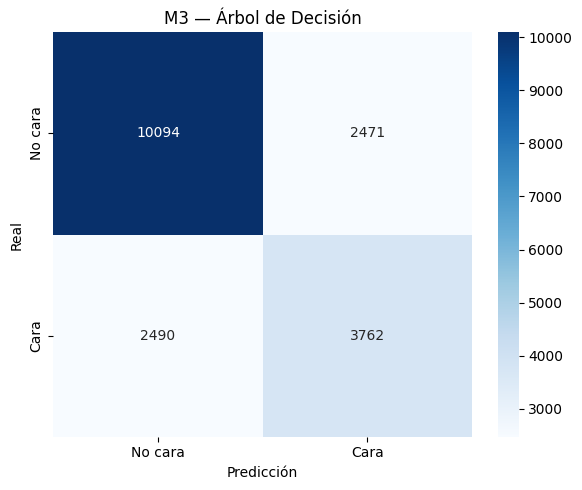

In [26]:
dt_model = DecisionTreeClassifier(random_state=random_state)
dt_model.fit(X_train, y_train_cara)

y_pred_dt = dt_model.predict(X_test)

print("=== M3: Árbol de Decisión ===")
print(f"\nAccuracy: {accuracy_score(y_test_cara, y_pred_dt):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred_dt, target_names=['No cara', 'Cara']))

cm_dt = confusion_matrix(y_test_cara, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.title('M3 — Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 10.2 Random Forest (M4)

=== M4: Random Forest ===

Accuracy: 0.7967

Reporte de clasificación:
              precision    recall  f1-score   support

     No cara       0.83      0.88      0.85     12565
        Cara       0.73      0.63      0.67      6252

    accuracy                           0.80     18817
   macro avg       0.78      0.75      0.76     18817
weighted avg       0.79      0.80      0.79     18817



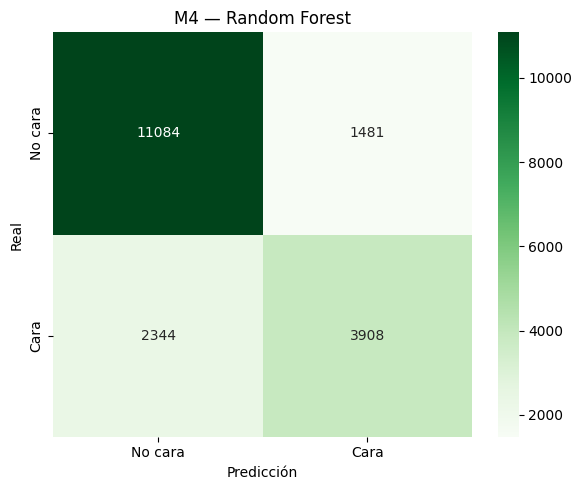

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_model.fit(X_train, y_train_cara)

y_pred_rf = rf_model.predict(X_test)

print("=== M4: Random Forest ===")
print(f"\nAccuracy: {accuracy_score(y_test_cara, y_pred_rf):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred_rf, target_names=['No cara', 'Cara']))

cm_rf = confusion_matrix(y_test_cara, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.title('M4 — Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 10.3 Naive Bayes (M5)

=== M5: Naive Bayes (GaussianNB) ===

Accuracy: 0.7673

Reporte de clasificación:
              precision    recall  f1-score   support

     No cara       0.84      0.80      0.82     12565
        Cara       0.64      0.70      0.67      6252

    accuracy                           0.77     18817
   macro avg       0.74      0.75      0.74     18817
weighted avg       0.77      0.77      0.77     18817



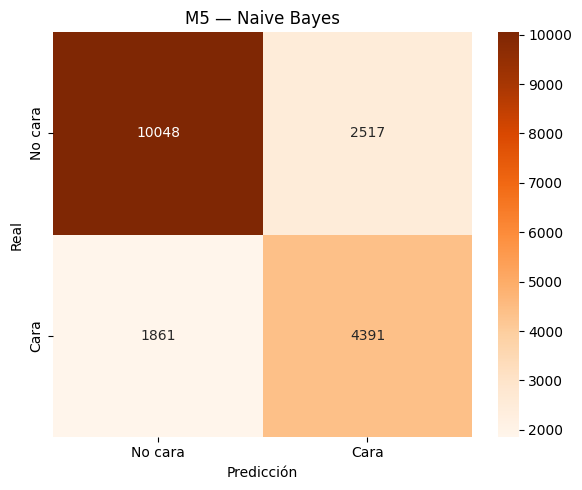

In [28]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train_cara)

y_pred_nb = nb_model.predict(X_test)

print("=== M5: Naive Bayes (GaussianNB) ===")
print(f"\nAccuracy: {accuracy_score(y_test_cara, y_pred_nb):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred_nb, target_names=['No cara', 'Cara']))

cm_nb = confusion_matrix(y_test_cara, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.title('M5 — Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 10.4 K-Nearest Neighbors (M6)

=== M6: K-Nearest Neighbors (k=5) ===

Accuracy: 0.7737

Reporte de clasificación:
              precision    recall  f1-score   support

     No cara       0.81      0.86      0.84     12565
        Cara       0.68      0.60      0.64      6252

    accuracy                           0.77     18817
   macro avg       0.75      0.73      0.74     18817
weighted avg       0.77      0.77      0.77     18817



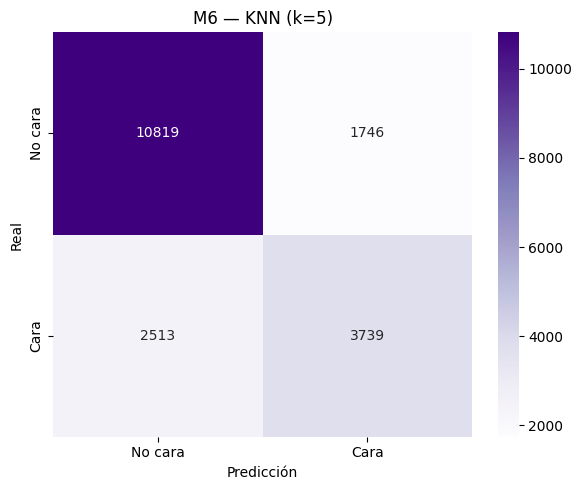

In [29]:
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train_cara)

y_pred_knn = knn_model.predict(X_test)

print("=== M6: K-Nearest Neighbors (k=5) ===")
print(f"\nAccuracy: {accuracy_score(y_test_cara, y_pred_knn):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred_knn, target_names=['No cara', 'Cara']))

cm_knn = confusion_matrix(y_test_cara, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No cara', 'Cara'],
            yticklabels=['No cara', 'Cara'])
plt.title('M6 — KNN (k=5)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### 10.5 Comparación y Conclusión de Modelos Adicionales

#### Tabla resumen de métricas (clase "Cara")

| Modelo | Accuracy | Precision (cara) | Recall (cara) | F1 (cara) |
|--------|----------|-----------------|---------------|-----------|
| M1 — Regresión Logística (referencia) | 0.7903 | 0.73 | 0.59 | 0.65 |
| M3 — Árbol de Decisión | 0.7364 | 0.60 | 0.60 | 0.60 |
| M4 — Random Forest | **0.7967** | **0.73** | **0.63** | **0.67** |
| M5 — Naive Bayes | 0.7673 | 0.64 | 0.70 | 0.67 |
| M6 — KNN (k=5) | 0.7737 | 0.68 | 0.60 | 0.64 |

---

#### Análisis por modelo

**M3 — Árbol de Decisión**  
Es el modelo con peor desempeño general: accuracy de 0.7364, el más bajo del conjunto. La precision y recall de la clase "Cara" son iguales (0.60), lo que indica que el árbol no favorece ninguna clase en particular, pero lo hace a un nivel inferior al resto de los modelos. Un árbol sin poda tiende a sobreajustarse al conjunto de entrenamiento y generalizar peor, lo cual es consistente con estos resultados.

**M4 — Random Forest**  
Es el modelo con mejor accuracy global (0.7967) y el mejor F1 para la clase "Cara" (0.67), junto con Naive Bayes. Supera a la Regresión Logística de referencia (M1) en todas las métricas de la clase "Cara": mayor precision (0.73 vs 0.73), mayor recall (0.63 vs 0.59) y mayor F1 (0.67 vs 0.65). El conjunto de 100 árboles con votación reduce la varianza respecto al árbol individual y captura relaciones no lineales entre las variables.

**M5 — Naive Bayes**  
Obtiene el **recall más alto de todos los modelos para la clase "Cara" (0.70)**, lo que significa que detecta más propiedades caras correctamente que cualquier otro clasificador. Su F1 es 0.67, igual que Random Forest. Sin embargo, su precision es la más baja (0.64), lo que implica más falsos positivos. En contextos donde detectar propiedades caras es prioritario (minimizar falsos negativos), este modelo es especialmente valioso a pesar de su menor accuracy global (0.7673).

**M6 — KNN (k=5)**  
Obtiene un desempeño intermedio (accuracy 0.7737, F1 cara 0.64). Su recall de 0.60 es idéntico al del Árbol de Decisión pero con mejor precision (0.68 vs 0.60). KNN es sensible a la escala de las variables y a la dimensionalidad; sin normalización previa de los predictores, su rendimiento puede estar limitado.

---

#### Conclusión

El **mejor modelo global es M4 — Random Forest**, con el mayor accuracy (0.7967) y el mejor F1 para la clase "Cara" (0.67), superando incluso al mejor modelo de regresión logística (M1, accuracy 0.7903, F1 cara 0.65). Si el criterio principal fuera **maximizar la detección de propiedades caras** (recall), entonces **M5 — Naive Bayes** sería la elección prioritaria con recall 0.70, a costa de mayor tasa de falsos positivos.

El Árbol de Decisión (M3) es el modelo más débil del conjunto y no se recomienda sin aplicar poda o ajuste de hiperparámetros.